In [12]:
#imports
import pandas as pd
from generate_schedule import generate_schedule
from sim_season import simulate_season
from random_fpi import make_random_fpi
from playoffs import playoff_field
from collections import Counter
from real_nfl_schedule import build_real_season_dfs,real_schedule_df
import matplotlib.pyplot as plt
from simulate_playoffs import simulate_playoffs
import nflreadpy as nfl
import numpy as np
from scipy.stats import linregress

df = pd.read_csv("FPI-1-11-26.csv")

dfs = {}
for year in range(2015, 2025):
    dfs[year] = pd.read_csv(f"FPI_Years/FPI_{year}.csv")
    
team_to_abbr = {"Arizona Cardinals":"ARI",
    "Atlanta Falcons":"ATL",
    "Baltimore Ravens":"BAL",
    "Buffalo Bills":"BUF",
    "Carolina Panthers":"CAR",
    "Chicago Bears":"CHI",
    "Cincinnati Bengals":"CIN",
    "Cleveland Browns":"CLE",
    "Dallas Cowboys":"DAL",
    "Denver Broncos":"DEN",
    "Detroit Lions":"DET",
    "Green Bay Packers":"GB",
    "Houston Texans":"HOU",
    "Indianapolis Colts":"IND",
    "Jacksonville Jaguars":"JAX",
    "Kansas City Chiefs":"KC",
    "Las Vegas Raiders":"LV",
    "Los Angeles Chargers":"LAC",
    "Los Angeles Rams":"LA",
    "Miami Dolphins":"MIA",
    "Minnesota Vikings":"MIN",
    "New England Patriots":"NE",
    "New Orleans Saints":"NO",
    "New York Giants":"NYG",
    "New York Jets":"NYJ",
    "Philadelphia Eagles":"PHI",
    "Pittsburgh Steelers":"PIT",
    "San Francisco 49ers":"SF",
    "Seattle Seahawks":"SEA",
    "Tampa Bay Buccaneers":"TB",
    "Tennessee Titans":"TEN",
    "Washington Commanders":"WAS"
    }

corrected_teams = {"Oakland Raiders": "Las Vegas Raiders",
                   "St. Louis Rams": "Los Angeles Rams",
                   "San Diego Chargers": "Los Angeles Chargers"}

In [13]:
from collections import Counter

n = 10000

one_seed_ranks = []
fpi_counts_nfl   = Counter()
fpi_counts_total = Counter()
fpi_counts_cap   = Counter()

for sim_seed in range(1, n + 1):
    df_seeded   = make_random_fpi(df, mean=-0.016, std=3, seed=sim_seed)
    schedule_df = generate_schedule(df_seeded, seed=sim_seed)

    # NFL method
    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)
    field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df)
    fpi_counts_nfl.update(Counter(fpi_winners))

    # total margin
    results_df_total, standings_df_total = simulate_season(df_seeded, schedule_df, seed=sim_seed)
    _, _, fpi_winners_total = playoff_field(standings_df_total, results_df_total, mode="total_margin")
    fpi_counts_total.update(Counter(fpi_winners_total))

    # capped margin
    results_df_cap, standings_df_cap = simulate_season(df_seeded, schedule_df, seed=sim_seed, tm_cap=10)
    _, _, fpi_winners_cap = playoff_field(standings_df_cap, results_df_cap, mode="capped_margin")
    fpi_counts_cap.update(Counter(fpi_winners_cap))

    standings_df["Conf_FPI_Rank"] = (
        standings_df.groupby("Conference")["FPI"]
        .rank(method="first", ascending=False).astype(int)
    )
    one_seeds = field[field["Seed"] == 1]["Team"]
    one_seed_rows = standings_df.loc[
        standings_df["Team"].isin(one_seeds), ["Team", "Conference", "Conf_FPI_Rank"]
    ].copy()
    one_seed_ranks.append(one_seed_rows)

Coin flip! Between ['Green Bay Packers', 'Arizona Cardinals']
Coin flip! Between ['Tampa Bay Buccaneers', 'New Orleans Saints']
Coin flip! Between ['New York Giants', 'Philadelphia Eagles']


In [16]:
fpi_counts_real_nfl   = Counter()
fpi_counts_real_total = Counter()
fpi_counts_real_cap   = Counter()

for year in range(2015, 2026):
    results_df_real, standings_df_real = build_real_season_dfs(year)

    if year in dfs:
        fpi_map = dict(zip(dfs[year]["Team"], dfs[year]["FPI"]))
        standings_df_real["FPI"] = standings_df_real["Team"].map(fpi_map)

    # NFL
    _, _, fpi_winners_real = playoff_field(standings_df_real, results_df_real)
    fpi_counts_real_nfl.update(Counter(fpi_winners_real))

    # total margin
    _, _, fpi_winners_real_total = playoff_field(standings_df_real, results_df_real, mode="total_margin")
    fpi_counts_real_total.update(Counter(fpi_winners_real_total))

    # capped
    results_df_cap, standings_df_cap = build_real_season_dfs(year, tm_cap=10)
    if year in dfs:
        standings_df_cap["FPI"] = standings_df_cap["Team"].map(fpi_map)
    _, _, fpi_winners_real_cap = playoff_field(standings_df_cap, results_df_cap, mode="capped_margin")
    fpi_counts_real_cap.update(Counter(fpi_winners_real_cap))

In [17]:
one_seed_ranks_df = pd.concat(one_seed_ranks, ignore_index=True)

def get_prop(counter):
    total = sum(counter.values())
    return counter["higher FPI won"] / total

sim_nfl   = get_prop(fpi_counts_nfl)
sim_total = get_prop(fpi_counts_total)
sim_cap   = get_prop(fpi_counts_cap)
real_nfl  = get_prop(fpi_counts_real_nfl)
real_total = get_prop(fpi_counts_real_total)
real_cap  = get_prop(fpi_counts_real_cap)

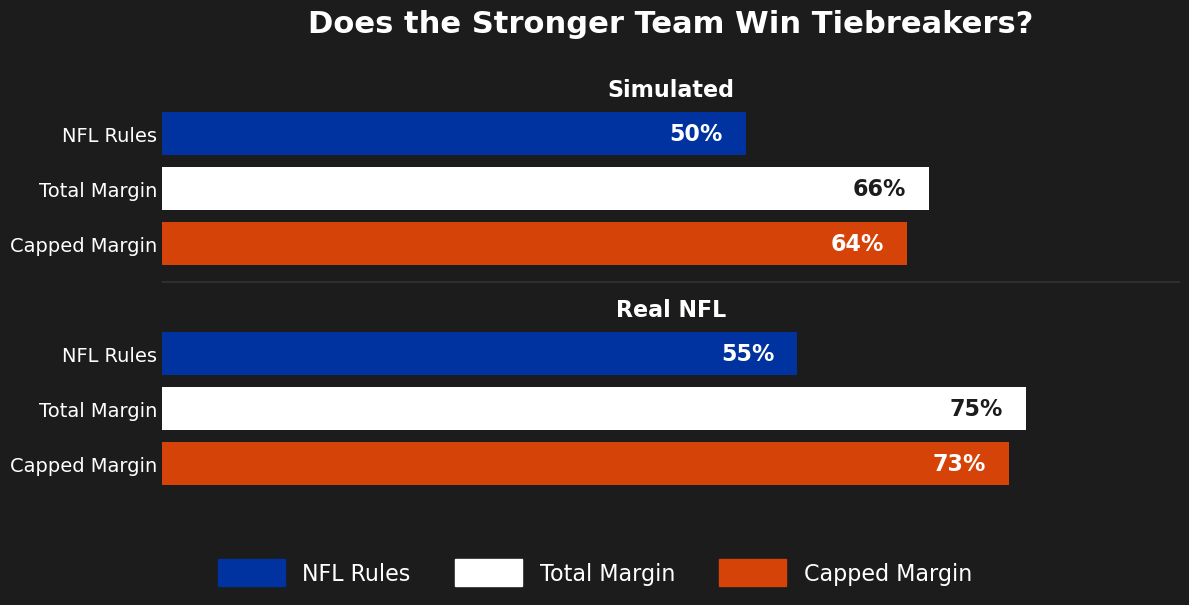

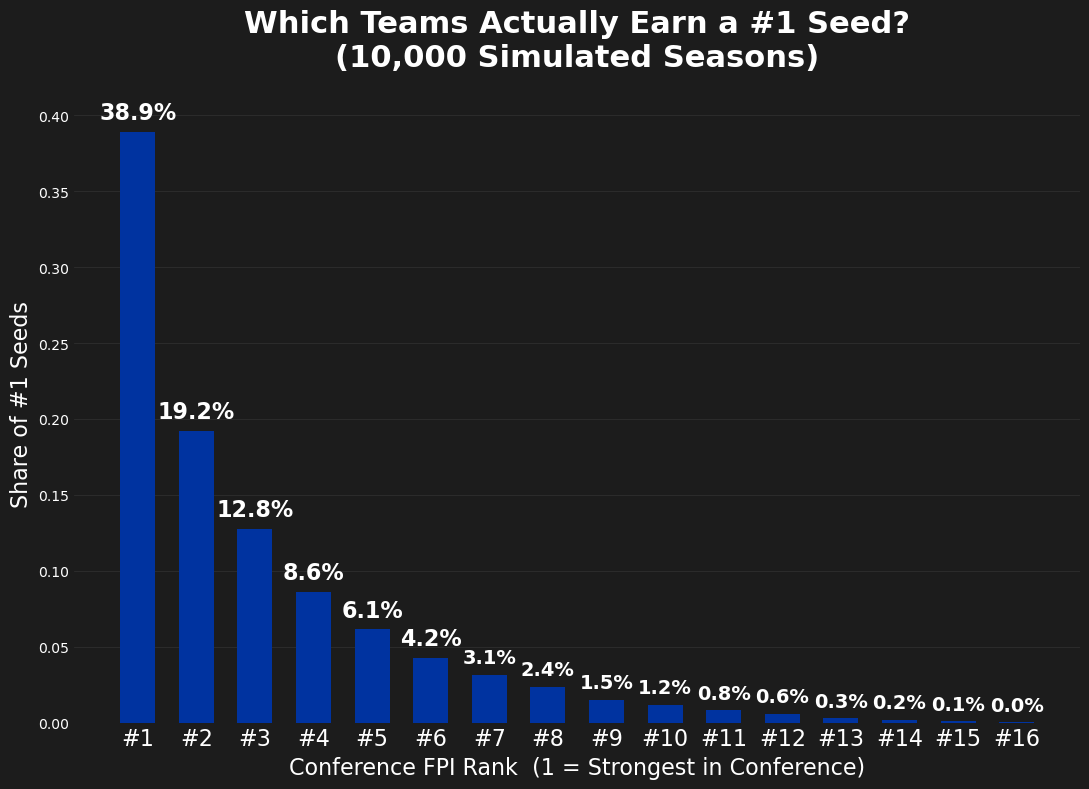

In [18]:
from importlib import reload
import poster_graphs_styled
reload(poster_graphs_styled)
from poster_graphs_styled import plot_accuracy_bars, plot_1seed_histogram

plot_accuracy_bars(sim_nfl, sim_total, sim_cap, real_nfl, real_total, real_cap)
plot_1seed_histogram(one_seed_ranks_df, max_rank=16)

In [ ]:
from scipy.stats import chisquare

observed = one_seed_ranks_df["Conf_FPI_Rank"].value_counts().sort_index().values
# fit a geometric distribution as expected frequencies
p = 0.09# tweak this — geometric decay parameter
expected = np.array([(1-p)**(i) * p for i in range(len(observed))])
expected = expected / expected.sum() * observed.sum()  # scale to same total

chi2, p_val = chisquare(f_obs=observed, f_exp=expected)
print(f"Chi-square: {chi2:.3f}, p-value: {p_val:.4f}")

In [ ]:
from scipy.stats import powerlaw
from scipy.optimize import curve_fit
observed = one_seed_ranks_df["Conf_FPI_Rank"].value_counts().reindex(range(1, 17), fill_value=0).values

ranks = np.arange(1, 17)
observed_probs = observed / observed.sum()

def power_law(x, a, b):
    return a * x**(-b)

popt, _ = curve_fit(power_law, ranks, observed_probs)
expected_power = power_law(ranks, *popt)
expected_power = expected_power / expected_power.sum() * observed.sum()

chi2, p_val = chisquare(f_obs=observed, f_exp=expected_power)
print(f"Power law fit — a={popt[0]:.3f}, b={popt[1]:.3f}")
print(f"Chi-square: {chi2:.3f}, p-value: {p_val:.4f}")

In [20]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

higher_sim = fpi_counts_cap["higher FPI won"]
total_sim  = sum(fpi_counts_cap.values())

higher_real = fpi_counts_real_cap["higher FPI won"]
total_real  = sum(fpi_counts_real_cap.values())

stat, p_val = proportions_ztest([higher_sim, higher_real], [total_sim, total_real])
print(f"p-value: {p_val:.4f}")
print(f"Significantly different (α=0.05): {p_val < 0.05}")

p-value: 0.1206
Significantly different (α=0.05): False


In [19]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

higher_sim = fpi_counts_total["higher FPI won"]
total_sim  = sum(fpi_counts_total.values())

higher_real = fpi_counts_real_total["higher FPI won"]
total_real  = sum(fpi_counts_real_total.values())

stat, p_val = proportions_ztest([higher_sim, higher_real], [total_sim, total_real])
print(f"p-value: {p_val:.4f}")
print(f"Significantly different (α=0.05): {p_val < 0.05}")

p-value: 0.1365
Significantly different (α=0.05): False


In [21]:
from scipy.stats import binomtest
higher_real_nfl = fpi_counts_real_nfl["higher FPI won"]
total_real_nfl  = sum(fpi_counts_real_nfl.values())

result = binomtest(higher_real_nfl, n=total_real_nfl, p=0.5, alternative="greater")
print(f"p-value: {result.pvalue:.4f}")
print(f"Statistically significant (α=0.05): {result.pvalue < 0.05}")

p-value: 0.2383
Statistically significant (α=0.05): False


In [2]:
import os

CACHE = "season_length_results.csv"

if os.path.exists(CACHE):
    results_df_summary = pd.read_csv(CACHE)
    print("Loaded from cache")
else:
    season_lengths = [12, 16, 17, 34, 50, 100, 250, 500, 1000, 2500, 5000, 10000]
    n_sims = 250
    results = []
    df = pd.read_csv("FPI-1-11-26.csv")

    for season_length in season_lengths:
        
        fpi_win_corrs = []
        one_seed_fpi_ranks = []
        best_team_one_seed_count = 0
        best_team_sb_count = 0
        
        for sim_seed in range(1, n_sims + 1):
            
            df_seeded = make_random_fpi(df, mean=-0.016, std=3, seed=sim_seed)
            schedule_df = generate_schedule(df_seeded, seed=sim_seed, season_length=season_length)
            results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)
            field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df)
            playoff_results_df, sb_winner = simulate_playoffs(df_seeded, field, seed=sim_seed)
            
            standings_temp = standings_df.copy()
            standings_temp["FPI_Rank"] = standings_temp["FPI"].rank(method="first", ascending=False)
            
            fpi_win_corrs.append(standings_temp["FPI"].corr(standings_temp["Wins"]))
            
            one_seed_rows = field[field["Seed"] == 1].merge(standings_temp[["Team", "FPI_Rank"]], on="Team", how="left")
            one_seed_fpi_ranks.extend(one_seed_rows["FPI_Rank"].tolist())
            
            best_fpi_team = standings_temp.sort_values("FPI", ascending=False)["Team"].iloc[0]
            
            if best_fpi_team in field[field["Seed"] == 1]["Team"].values:
                best_team_one_seed_count += 1
                
            if sb_winner == best_fpi_team:
                best_team_sb_count += 1
        
        results.append({"Season_Length": season_length,
            "Avg_FPI_Wins_Corr": np.mean(fpi_win_corrs), "Avg_1_Seed_FPI_Rank": np.mean(one_seed_fpi_ranks),
            "Best_FPI_Team_1_Seed_Prob": best_team_one_seed_count / n_sims, "Best_FPI_Team_SB_Prob": best_team_sb_count / n_sims})
        print("Done with", season_length)

    results_df_summary = pd.DataFrame(results)
    results_df_summary.to_csv(CACHE, index=False)
    print("Saved to cache")

Loaded from cache


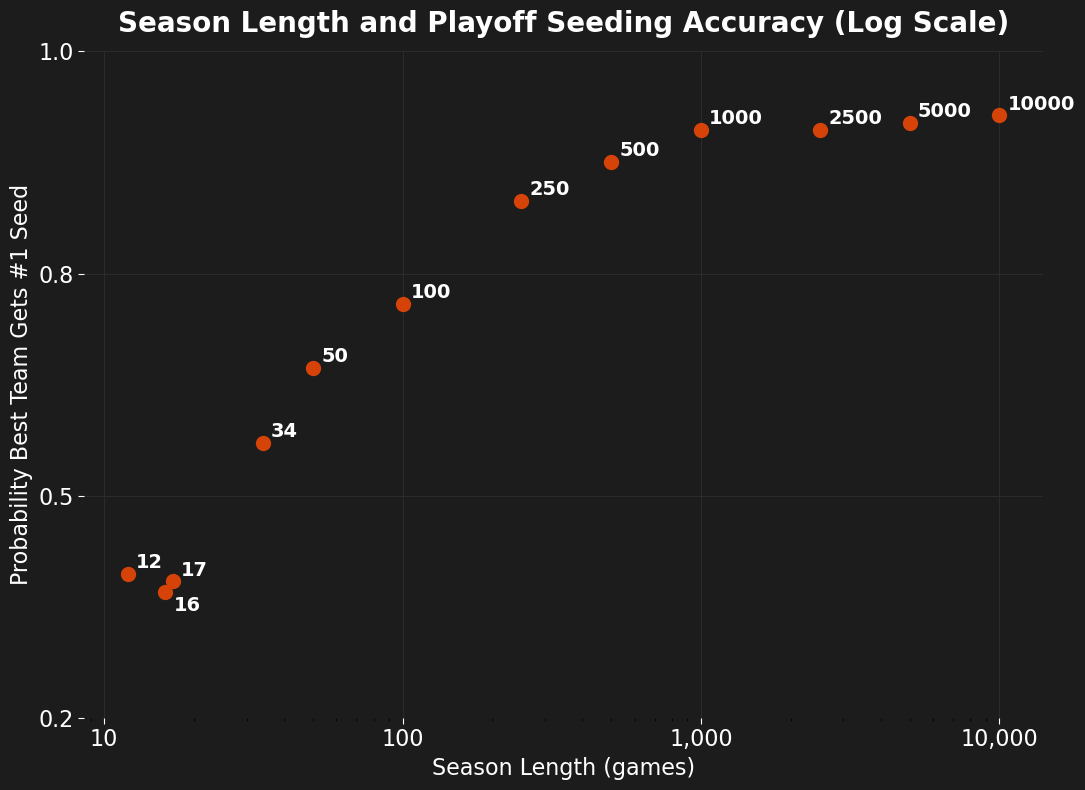

In [6]:
import importlib
import poster_graphs_styled
importlib.reload(poster_graphs_styled)
from poster_graphs_styled import plot_season_length

plot_season_length(results_df_summary)